# Tarea 2

En este notebook se realiza un análisis exploratorio de un conjunto de datos de temperaturas globales. Se estudian y rellenan los datos faltantes, se analiza la distribución de las temperaturas mediante histogramas, se identifican valores atípicos y posibles anomalías en las mediciones. Finalmente, se analiza la evolución de la temperatura media anual en distintas ciudades y su comportamiento a lo largo del tiempo.

In [266]:
# Por buenas prácticas vamos a importar las librerias que vamos a usar al principio 
# Esta es la única vez que lo pondré como comentario, las demás las podré directamente sin comentar
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

## Parte previa de los ejercicios 
Primero vamos a leer el archivo, una vez leído vamos a ver que información tiene, que tipo de datos contiene, cuántos datos tiene. 

Nos interesa mucho el rellenar datos, así que exploremos cuantos datos nulos tiene.

In [267]:
"""Vamos a leer el archivo, en la clase nos piden que vemos algunas funciones para el DataFrame 
así que vamos a explorar algunas, sin comentarlas, ya que fueron comentadas en clase."""
df = pd.read_csv(r'GLT_filtrado.csv', encoding='utf-8') 


print("Los primeros datos son :  \n ", df.head())
print("\n Tenemos información general sobre el DataFrame:  \n ", df.info())
print("\n Tenemos el tipo de datos dentro del DataFrame:  \n ", type(df))
print(df.dtypes)
# El ejercicio nos pide rellenar los datos nullos así que vamos a ver como son 
print("Tenemos los datos nulos \n", df.isnull().sum())

# Vamos a ver como se concentran los datos. 
print("Esta una estádistica de los datos \n", df.describe())

Los primeros datos son :  
           Date  AverageTemperature  AverageTemperatureUncertainty     City  \
0  1849-01-01              26.704                          1.435  Abidjan   
1  1849-02-01              27.434                          1.362  Abidjan   
2  1849-03-01                 NaN                            NaN  Abidjan   
3  1849-04-01              26.140                          1.387  Abidjan   
4  1849-05-01              25.427                          1.200  Abidjan   

         Country Latitude Longitude  
0  Côte D'Ivoire    5.63N     3.23W  
1  Côte D'Ivoire    5.63N     3.23W  
2  Côte D'Ivoire    5.63N     3.23W  
3  Côte D'Ivoire    5.63N     3.23W  
4  Côte D'Ivoire    5.63N     3.23W  
<class 'pandas.DataFrame'>
RangeIndex: 219575 entries, 0 to 219574
Data columns (total 7 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Date                           219575 non-null  str   

## Relleno de datos
Vamos a crear un psudocódigo, y el código esperemos que nos salga, sino pues de todas formas vamos a comparar con el rellenado de datos con las funciones de pandas, porque rellenar datos lo podemos hacer de diferentes maneras, así que no nos vamos a limitar a este método de rellenar el promedio de los datos laterales de nuestro conjunto. 

 ### Psudocódigo 



In [268]:
"""vamos a crear una función que haga que si hay un dato faltante lo rellene con el promedio de los extremos


Vamos a pedir los datos ya sea en forma de lista, arreglo np o pd
Vamos a poner los datos salida float y si está vacía colocamos un NaN
Para cada posición i en el arreglo se va a hacer:
    
    Si la posición inicial o la final son valores vacios entonces:
        Recorre la posición hasta encontrar un valor, divide entre dos y colocalo como inicial
        o recorre la posición antes del final con valor, divide entre dos y colocalo como final 

    si la posición incial y la final tienen valores entonces: 
            si en la i-ésima>0 posición está vacía entonces:
                toma los valores de las i-j, i+n-ésimas posiciones que tengan valor
                , calcula el promedio y el valor colocalo en la i-ésima posición
               
        
        
        
        
        
        """

'vamos a crear una función que haga que si hay un dato faltante lo rellene con el promedio de los extremos\n\n\nVamos a pedir los datos ya sea en forma de lista, arreglo np o pd\nVamos a poner los datos salida float y si está vacía colocamos un NaN\nPara cada posición i en el arreglo se va a hacer:\n\n    Si la posición inicial o la final son valores vacios entonces:\n        Recorre la posición hasta encontrar un valor, divide entre dos y colocalo como inicial\n        o recorre la posición antes del final con valor, divide entre dos y colocalo como final \n\n    si la posición incial y la final tienen valores entonces: \n            si en la i-ésima>0 posición está vacía entonces:\n                toma los valores de las i-j, i+n-ésimas posiciones que tengan valor\n                , calcula el promedio y el valor colocalo en la i-ésima posición\n\n\n\n\n\n\n        '

Como vamos convertimos nuestros datos en un DataFrame, el código lo haremos para un DataFrame, aunque es más fácil para un arreglo numpy o lista, el código que primero programé, está en el aparatado de *código previo*, como tal, es el pseudocódigo programado, así que solo comentaré partes importantes, porque como tal la explicación del código ya está. 

In [269]:
def datos_A_rellenar(datos):
    datos_rellenados = []  #Creamos nuestra lista vacía 

    for i in datos: # Vamos agregando los datos que no son vacios y los que si, los rellenamos con "NaN"
        if not pd.isna(i):
            datos_rellenados.append(float(i))
        else:
            datos_rellenados.append(np.nan)

    if np.isnan(datos_rellenados[0]): # Vamos primero por el extremo si está vacío

        for posicion, valor in enumerate(datos_rellenados): # Buscamos en nuestros datos el primer dato lleno

            if not np.isnan(valor):  
                datos_rellenados[0] = valor / 2
                break # Termina de ejecutarse cuando rellena el valor y ya tenemos el incio 

    if np.isnan(datos_rellenados[-1]): #Básicamente es lo mismo que el de arriba pero empezando por el último 

        for posicion, valor in enumerate(datos_rellenados[::-1]):

            if not np.isnan(valor):
                datos_rellenados[-1] = valor / 2
                break # Ahora tenemos los dos extremos llenos

    for posicion, valor in enumerate(datos_rellenados):
        #Vamos por los que están en medio 
        if np.isnan(valor):
            
            anterior = None #Para que se vea profecional usamos None pero pudimos usar un cero 
            siguiente = None

            # Buscar hacia atrás
            for j in range(posicion - 1, -1, -1):
                if not np.isnan(datos_rellenados[j]):
                    anterior = datos_rellenados[j]
                    break

            # Buscar hacia adelante
            for j in range(posicion + 1, len(datos_rellenados)):
                if not np.isnan(datos_rellenados[j]):
                    siguiente = datos_rellenados[j]
                    break

            if anterior is not None and siguiente is not None:
                datos_rellenados[posicion] = (anterior + siguiente) / 2

    return datos_rellenados

In [270]:
columna_previa  = df["AverageTemperature"]
columa_rellenada = datos_A_rellenar(columna_previa)
columa_rellenada = pd.Series(columa_rellenada)



In [271]:
df["AverageTemperature rellenada"] = columa_rellenada


In [272]:
d = df[df['AverageTemperature'].isna()]

d.head(10)

,Date,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,AverageTemperature rellenada
2,1849-03-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.787000
8,1849-09-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W,24.419500
23,1850-12-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.452500
24,1851-01-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.907750
28,1851-05-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W,25.751000
34,1851-11-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W,25.670500
36,1852-01-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.446000
37,1852-02-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.567500
38,1852-03-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.628250
39,1852-04-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.658625


Vamos a probarlo con el código del profesor y comparar los resultados.

In [273]:
df_copia = df.copy()

# guardar las primeras 10 filas ANTES
antes_rellenar = df_copia[df_copia['AverageTemperature'].isna()].head(10).copy()
print("ANTES de rellenar valores faltantes:")
print(antes_rellenar[['City', 'AverageTemperature']])

# orden
df_copia = df_copia.sort_values(['City', 'Date'])

# aplicar la función
for ciudad in df_copia['City'].unique():
    indice_ciudad = df_copia['City'] == ciudad
    temperaturas = df_copia.loc[indice_ciudad, 'AverageTemperature'].tolist()
    temperaturas_rellenadas = datos_A_rellenar(temperaturas) # Aquí cambiamos la linea para usar nuestro programa
    df_copia.loc[indice_ciudad, 'AverageTemperature'] = temperaturas_rellenadas

# DESPUÉS de rellenaR
despues_rellenar = df_copia.loc[antes_rellenar.index]
print("\nDESPUÉS de rellenar valores faltantes:")
print(despues_rellenar[['City', 'AverageTemperature']])

ANTES de rellenar valores faltantes:
       City  AverageTemperature
2   Abidjan                 NaN
8   Abidjan                 NaN
23  Abidjan                 NaN
24  Abidjan                 NaN
28  Abidjan                 NaN
34  Abidjan                 NaN
36  Abidjan                 NaN
37  Abidjan                 NaN
38  Abidjan                 NaN
39  Abidjan                 NaN

DESPUÉS de rellenar valores faltantes:
       City  AverageTemperature
2   Abidjan           26.787000
8   Abidjan           24.419500
23  Abidjan           26.452500
24  Abidjan           26.907750
28  Abidjan           25.751000
34  Abidjan           25.670500
36  Abidjan           26.446000
37  Abidjan           26.567500
38  Abidjan           26.628250
39  Abidjan           26.658625


Al parecer, tenemos los mismos datos rellenados. Así que vamos a seguir con la parte de los ejercicios

## Ejercicio 1 
### Parte 1 Realizar un histograma
En esta parte vamos hacer dos histogramas uno relacionado a los datos sin rellenar y otro usando los datos rellenados ya que debemos de tener cuidado porque son datos que nos estamos inventado. 



In [274]:
def histograma_general(columna_df):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.hist(columna_df, density=True, bins=60 , alpha=0.6, color="blue", label = "Datos sin rellenar")
    plt.legend(loc = "best")
    plt.title("Distribución de temperaturas global")
    plt.xlabel("temperatura medida")
    plt.ylabel("Frencuencia")
    plt.subplot(1, 2, 2)
    plt.hist(datos_A_rellenar(columna_df), bins=60,  density=True, alpha=0.6, color="blue", label = "Rellenados con nuestro programa")
    plt.legend(loc = "best")
    plt.title("Distribución de temperaturas global")
    plt.xlabel("temperatura medida")
    plt.ylabel("Frencuencia")
    plt.show()

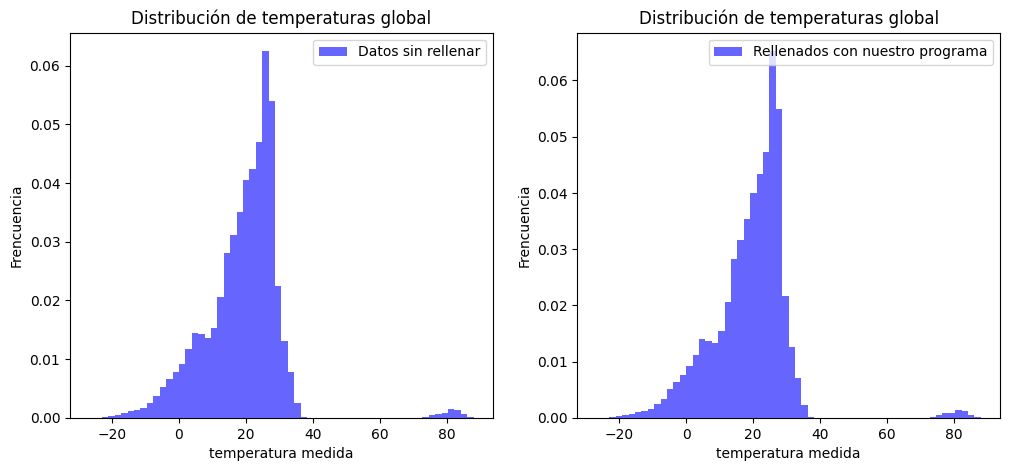

In [275]:
columna_previa  = df["AverageTemperature"]
histograma_general(columna_previa)

Notamos que hay frecuencias extremandamente grandes, pero lo que nos intereza son los valores medidos que tienen valores cercanos a 80 grados, entre 73-95 grados aproximandamente (visualizado en la gráfica, más no corroborado).

Aplicando un filtro podemos ver cuales son esas termperaturas, y podemos notar que son 2001 datos los que causan esa anomalía.

In [276]:
Temperaturas_altas = df[df['AverageTemperature']>=60]

print(Temperaturas_altas.head(10))
print(Temperaturas_altas.info())

             Date  AverageTemperature  AverageTemperatureUncertainty     City  \
18012  1817-01-01             75.1820                        38.4746  Bangkok   
18013  1817-02-01             80.2148                        35.6846  Bangkok   
18014  1817-03-01             82.2164                        35.2796  Bangkok   
18015  1817-04-01             84.4268                        35.2400  Bangkok   
18016  1817-05-01             81.2948                        35.4632  Bangkok   
18017  1817-06-01             79.3832                        34.5686  Bangkok   
18019  1817-08-01             81.1112                        34.6370  Bangkok   
18020  1817-09-01             75.9632                        35.7980  Bangkok   
18021  1817-10-01             75.5672                        36.0050  Bangkok   
18022  1817-11-01             76.2980                        35.7926  Bangkok   

        Country Latitude Longitude  AverageTemperature rellenada  
18012  Thailand   13.66N    99.91E       

Podemos notar que son producidas por Thailand

In [277]:
Cuidad_alta = df[(df['Country']== "Thailand") & (df['AverageTemperature']>=60)]
Cuidad_alta.info()

<class 'pandas.DataFrame'>
Index: 2001 entries, 18012 to 20363
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           2001 non-null   str    
 1   AverageTemperature             2001 non-null   float64
 2   AverageTemperatureUncertainty  2001 non-null   float64
 3   City                           2001 non-null   str    
 4   Country                        2001 non-null   str    
 5   Latitude                       2001 non-null   str    
 6   Longitude                      2001 non-null   str    
 7   AverageTemperature rellenada   2001 non-null   float64
dtypes: float64(3), str(5)
memory usage: 140.7 KB


### Parte 2 Calcular los límites 


In [278]:
data_no_outliers = df.copy() #Creamos una copia
for col in data_no_outliers.select_dtypes(include=[np.number]).columns:
    Q1 = data_no_outliers[col].quantile(0.25) # Primer quartile (25%)
    Q3 = data_no_outliers[col].quantile(0.75) # Tercer quartile (75%)
    IQR = Q3 - Q1 # Rango interquartile
    # limites IQR
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
# contador
    outliers_count = (
    (data_no_outliers[col] < lower_bound)
    | (data_no_outliers[col] > upper_bound)
    ).sum()
    # apping
    data_no_outliers[col] = np.clip(data_no_outliers[col], lower_bound, upper_bound)
    print(f"{col}: {outliers_count} outliers capped | Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print("\nOutlier capping completed.")

AverageTemperature: 6444 outliers capped | Bounds: [-5.67, 45.18]

Outlier capping completed.
AverageTemperatureUncertainty: 8320 outliers capped | Bounds: [-0.90, 2.38]

Outlier capping completed.
AverageTemperature rellenada: 7793 outliers capped | Bounds: [-5.00, 44.75]

Outlier capping completed.


In [279]:
data_no_outliers.head(10)

,Date,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,AverageTemperature rellenada
0,1849-01-01,26.704,1.435,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.7040
1,1849-02-01,27.434,1.362,Abidjan,Côte D'Ivoire,5.63N,3.23W,27.4340
2,1849-03-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.7870
3,1849-04-01,26.140,1.387,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.1400
4,1849-05-01,25.427,1.200,Abidjan,Côte D'Ivoire,5.63N,3.23W,25.4270
5,1849-06-01,24.844,1.402,Abidjan,Côte D'Ivoire,5.63N,3.23W,24.8440
6,1849-07-01,24.058,1.254,Abidjan,Côte D'Ivoire,5.63N,3.23W,24.0580
7,1849-08-01,23.576,1.265,Abidjan,Côte D'Ivoire,5.63N,3.23W,23.5760
8,1849-09-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W,24.4195
9,1849-10-01,25.263,1.175,Abidjan,Côte D'Ivoire,5.63N,3.23W,25.2630


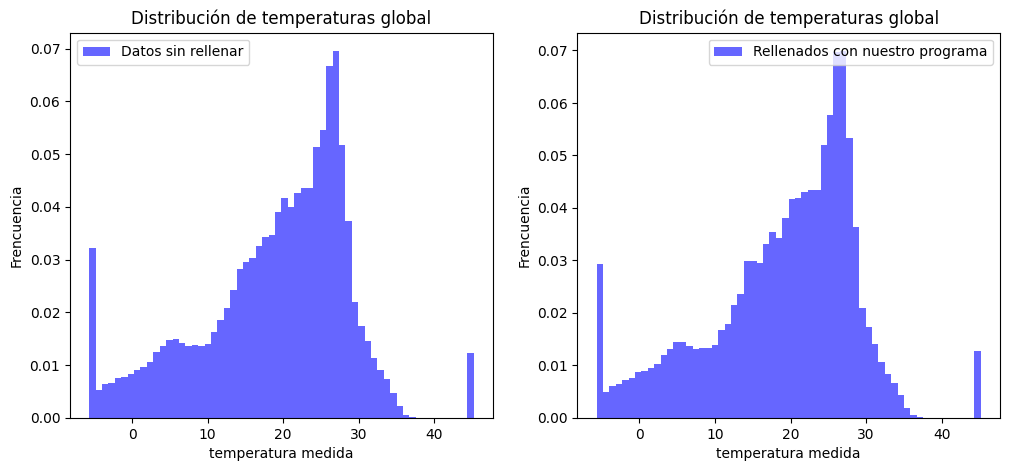

In [280]:
columna_previa  = data_no_outliers["AverageTemperature"]
histograma_general(columna_previa)

In [281]:
Q1 = df['AverageTemperature'].quantile(0.25)
Q3 = df['AverageTemperature'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['AverageTemperature'] < lower_bound) |
    (df['AverageTemperature'] > upper_bound)
]

print("Límite inferior:", lower_bound)
print("Límite superior:", upper_bound)
print("Número de outliers:", len(outliers))
outliers['City'].value_counts()

Límite inferior: -5.670499999999999
Límite superior: 45.1815
Número de outliers: 6444


City
Bangkok             2001
Harbin               697
Changchun            588
Montreal             546
Moscow               477
Shenyang             454
Toronto              398
Taiyuan              362
Saint Petersburg     337
Kiev                 227
Dalian                80
Peking                64
Tianjin               62
New York              49
Seoul                 29
Tangshan              24
Berlin                23
Chicago               14
Mashhad                7
Ankara                 4
Xian                   1
Name: count, dtype: int64

Podemos notar que la mayoria de los outliers están producidos por Bangkok, Harbin, Changchun,  y Montreal pero principalmente son por Bangkok que ya habiamos notado por la gráfica y el filtrado que pusimos. Los demás outliers son de la parte inferior. 


## Ejercio 2 



2. Como puedes ver, la ciudad X tiene distribuciones de temperatura muy
diferentes. Sin embargo, lo que resulta extraño es la gran diferencia en
la magnitud de sus temperaturas. Es posible que todos los sensores de
las estaciones estuvieran defectuosos?, ¿Qué crees que pudo haber sucedido
aquí? Usa tu creatividad para analizarlo y proponer una explicación.

Si la cuidad de Bangkok en Tailandia tiene la mayoria de los outliers, sus temperaturas son demasiado altas. Para empezar, investigando, si llega a una temperatura a más de 80°C práticamente la vida en la tierra dejaría de existir, así que si, es una anomalía. 
Quizás si, todos los sensores estaban defectusoso, pero también creo que es importante analizar la parte de las incertidumbres, ya que si es alta, pues puede contribuir a la medición de los datos. Vamos a comprobarlo 

Dejando de lado los titulos de nuestras gráficas, podemos notar que si, hay una anomalía en la incertidumbre de los datos. Entre 30-40 grados se encuentra la insertidumbre, mientras que la mayoria se concentra en el 0-5°C
Si aplicamos un filtrado podemos notar que coinciden con los datos de Tailandia, así que la incertidumbre es un factor que afecta directamente a los datos que tenemos porque si nuestra medición está entre 73-95 °C, pero su incertidumbre está en 30-40° pues nuestra medición hace sentido, ya que si tomo 73-30 = 43°C el dato ya no está tan alejado de los datos generales. De hecho entra en nuestro capping aunque sigan siendo altos los valores.  

Ahora, hay que analizar las unidades. 


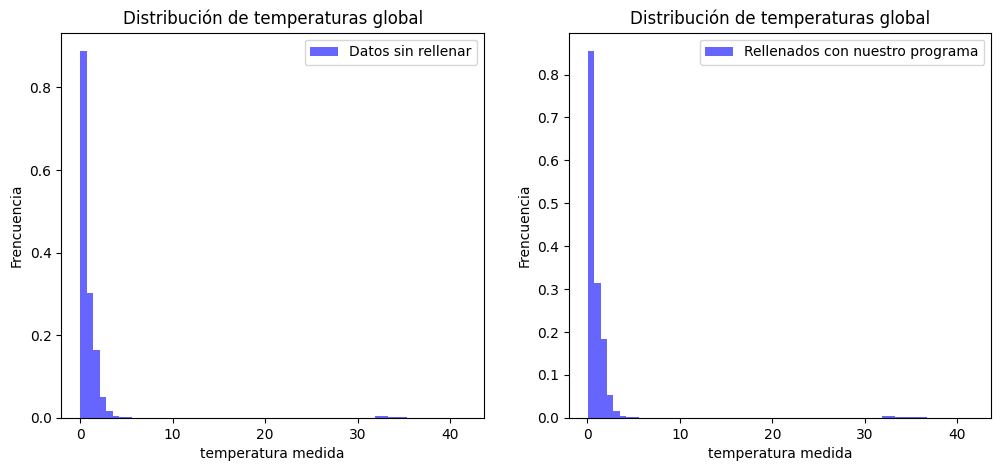

In [282]:
columna_previa  = df["AverageTemperatureUncertainty"]
histograma_general(columna_previa)


In [283]:
columan_de_insertidumbre_alta = df[df["AverageTemperatureUncertainty"]>20]
print("\n")
print(columan_de_insertidumbre_alta.head(15))
print("\n")
print(columan_de_insertidumbre_alta.info())
print("\n")
print(columan_de_insertidumbre_alta.describe())



             Date  AverageTemperature  AverageTemperatureUncertainty     City  \
18012  1817-01-01             75.1820                        38.4746  Bangkok   
18013  1817-02-01             80.2148                        35.6846  Bangkok   
18014  1817-03-01             82.2164                        35.2796  Bangkok   
18015  1817-04-01             84.4268                        35.2400  Bangkok   
18016  1817-05-01             81.2948                        35.4632  Bangkok   
18017  1817-06-01             79.3832                        34.5686  Bangkok   
18019  1817-08-01             81.1112                        34.6370  Bangkok   
18020  1817-09-01             75.9632                        35.7980  Bangkok   
18021  1817-10-01             75.5672                        36.0050  Bangkok   
18022  1817-11-01             76.2980                        35.7926  Bangkok   
18023  1817-12-01             71.4686                        36.3200  Bangkok   
18024  1818-01-01         

Si tomamos en cuenta que midieron en grados °F y lo pasamos a °C pues los datos se acomodan de mejor forma, así que en realidad creo que es un tema de unidades. 
Así que podemos repetir los historgramas con los nuevos valores y como es la tendencia. 

In [284]:
columan_de_insertidumbre_alta_tailandia_new = df[(df["AverageTemperatureUncertainty"]>20) & (df["City"]== "Bangkok")]

columan_de_alta_tailandia_new = df[(df["AverageTemperature"]>50) & (df["City"]== "Bangkok")]


columan_de_insertidumbre_alta_tailandia_new["AverageTemperatureUncertainty"] = (
    columan_de_insertidumbre_alta_tailandia_new["AverageTemperatureUncertainty"] - 32
) / 1.8
columan_de_alta_tailandia_new["AverageTemperature"] = (
    columan_de_alta_tailandia_new["AverageTemperature"] - 32
) / 1.8

print("\n")
print(columan_de_alta_tailandia_new.head(15))
print("\n")
print(columan_de_alta_tailandia_new.info())
print("\n")
print(columan_de_alta_tailandia_new.describe())



             Date  AverageTemperature  AverageTemperatureUncertainty     City  \
18012  1817-01-01              23.990                        38.4746  Bangkok   
18013  1817-02-01              26.786                        35.6846  Bangkok   
18014  1817-03-01              27.898                        35.2796  Bangkok   
18015  1817-04-01              29.126                        35.2400  Bangkok   
18016  1817-05-01              27.386                        35.4632  Bangkok   
18017  1817-06-01              26.324                        34.5686  Bangkok   
18019  1817-08-01              27.284                        34.6370  Bangkok   
18020  1817-09-01              24.424                        35.7980  Bangkok   
18021  1817-10-01              24.204                        36.0050  Bangkok   
18022  1817-11-01              24.610                        35.7926  Bangkok   
18023  1817-12-01              21.927                        36.3200  Bangkok   
18024  1818-01-01         

## Ejercicio 3 Temperatura media anual

Vamos a considerar Bangkok como originalmente lo tenemos sin la correción de los grados °C

In [285]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df.head(5)

,Date,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,AverageTemperature rellenada,Year
0,1849-01-01,26.704,1.435,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.704,1849
1,1849-02-01,27.434,1.362,Abidjan,Côte D'Ivoire,5.63N,3.23W,27.434,1849
2,1849-03-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.787,1849
3,1849-04-01,26.140,1.387,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.140,1849
4,1849-05-01,25.427,1.200,Abidjan,Côte D'Ivoire,5.63N,3.23W,25.427,1849


Pues podemos observar que a lo largo de los años se ha mantenido constante con fluctuaciones, pero sigue una tendencia constante en todas las cuidades. 

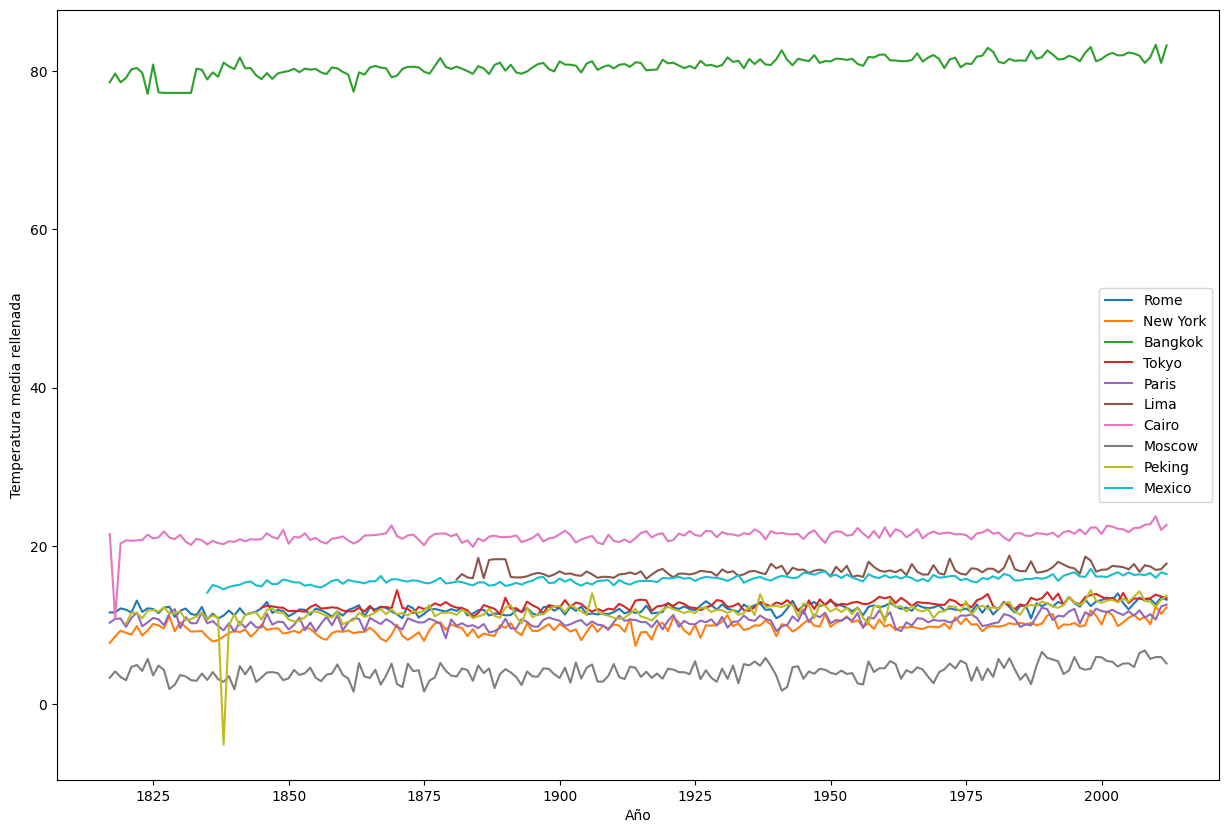

In [288]:
ciudades = ["Rome", "New York", "Bangkok", "Tokyo", "Paris", "Lima", "Cairo", "Moscow", "Peking", "Mexico"]
plt.figure(figsize=(15,10))
for i in ciudades:
    #print(i)
    df_por_cuidad_i = df[df["City"] == i]
    #print(df_por_cuidad_i)
    media_anual_i = df_por_cuidad_i.groupby('Year')["AverageTemperature rellenada"].mean()
    #print(media_anual_i.head(2))
    plt.plot(media_anual_i.index, media_anual_i, label = i)
plt.xlabel("Año")
plt.ylabel("Temperatura media rellenada")
plt.legend(loc = "best")
plt.show()


Ahora si se observa que el promedio va en aumento, en los diferentes lapsos de tiempo, con una regresión lineal se vería mejor. 
Pero como tal, si se ve que van en aumento. 

A simple vista, creo que Paris,  New York y Cairo podrían  ser las cuidades que más van en aumento. 
Cabe aclarar que los datos rellados afectan nuestras gráficas, así que podríamos intentar usar otro tipo de relleno y repetir el ejercicio para verificar. 

Además de corregir la cuidad de Bangkok

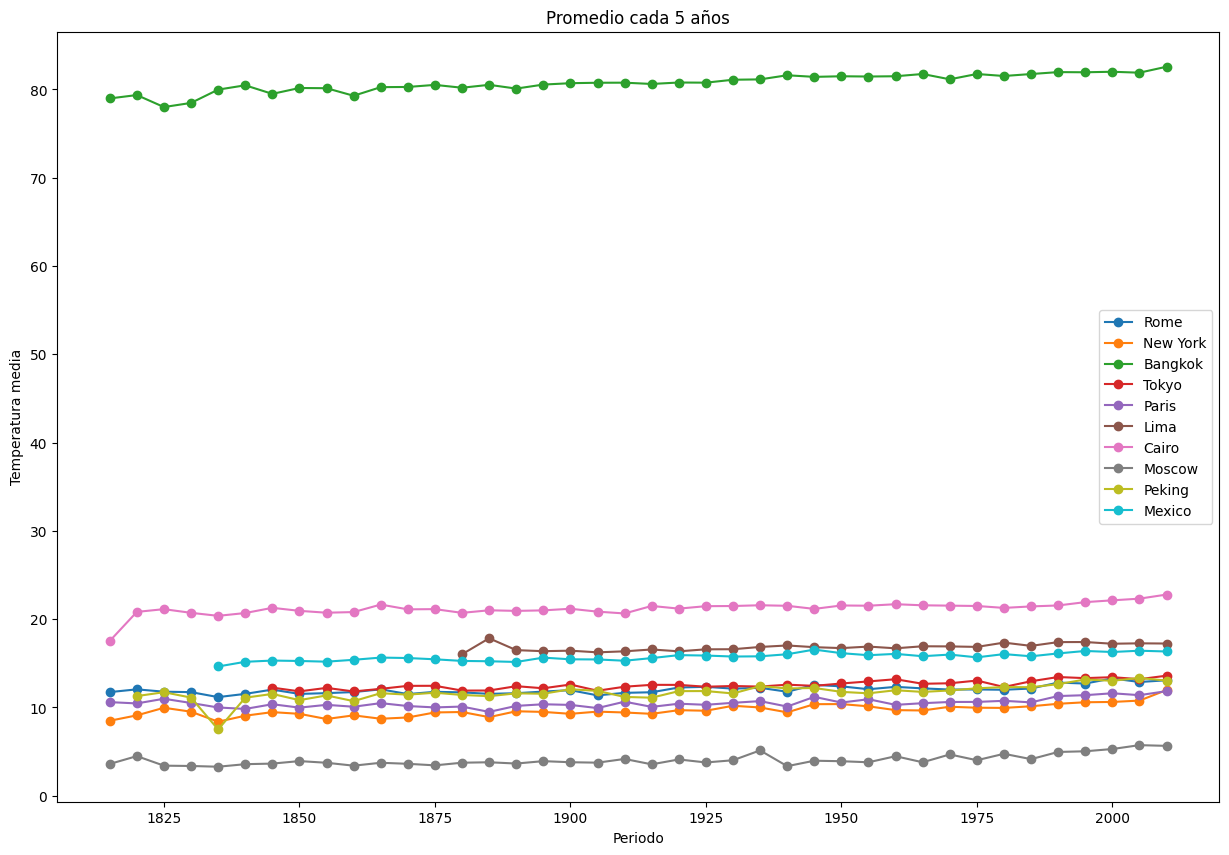

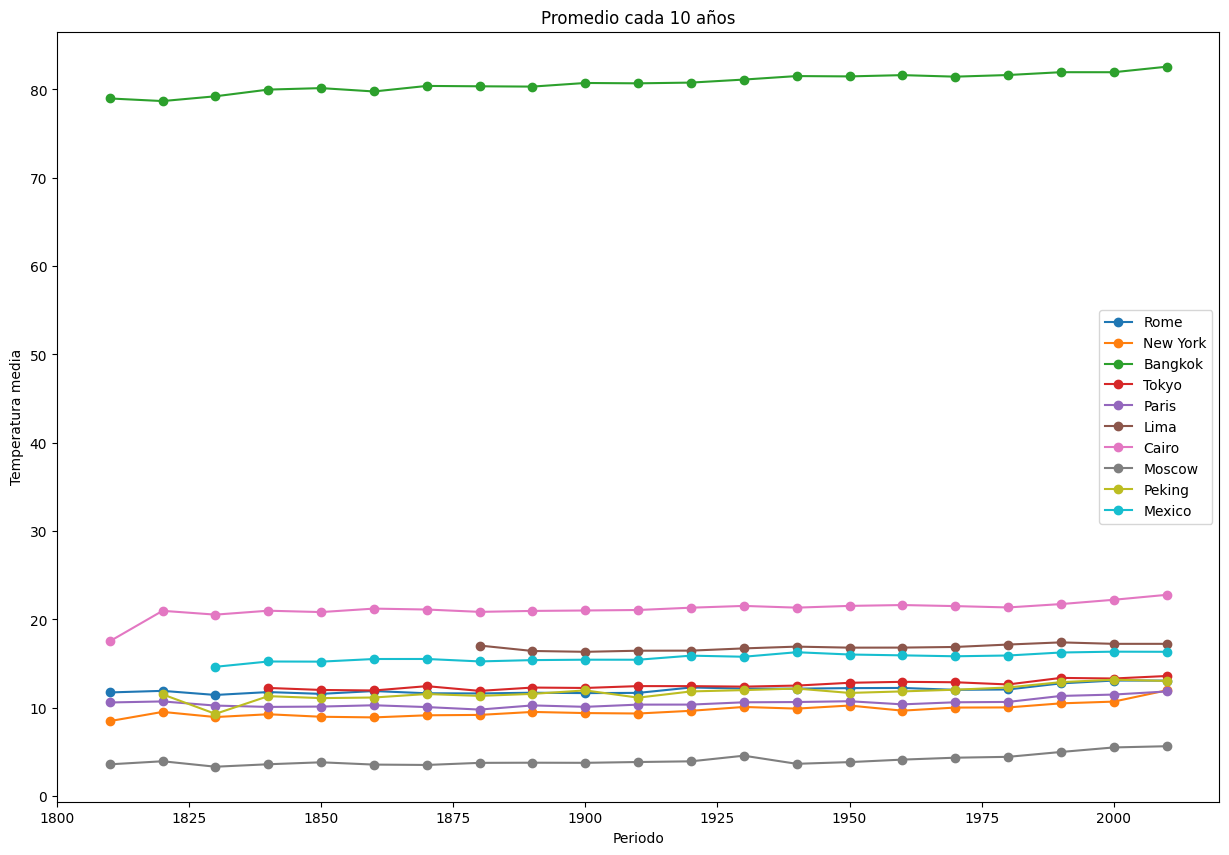

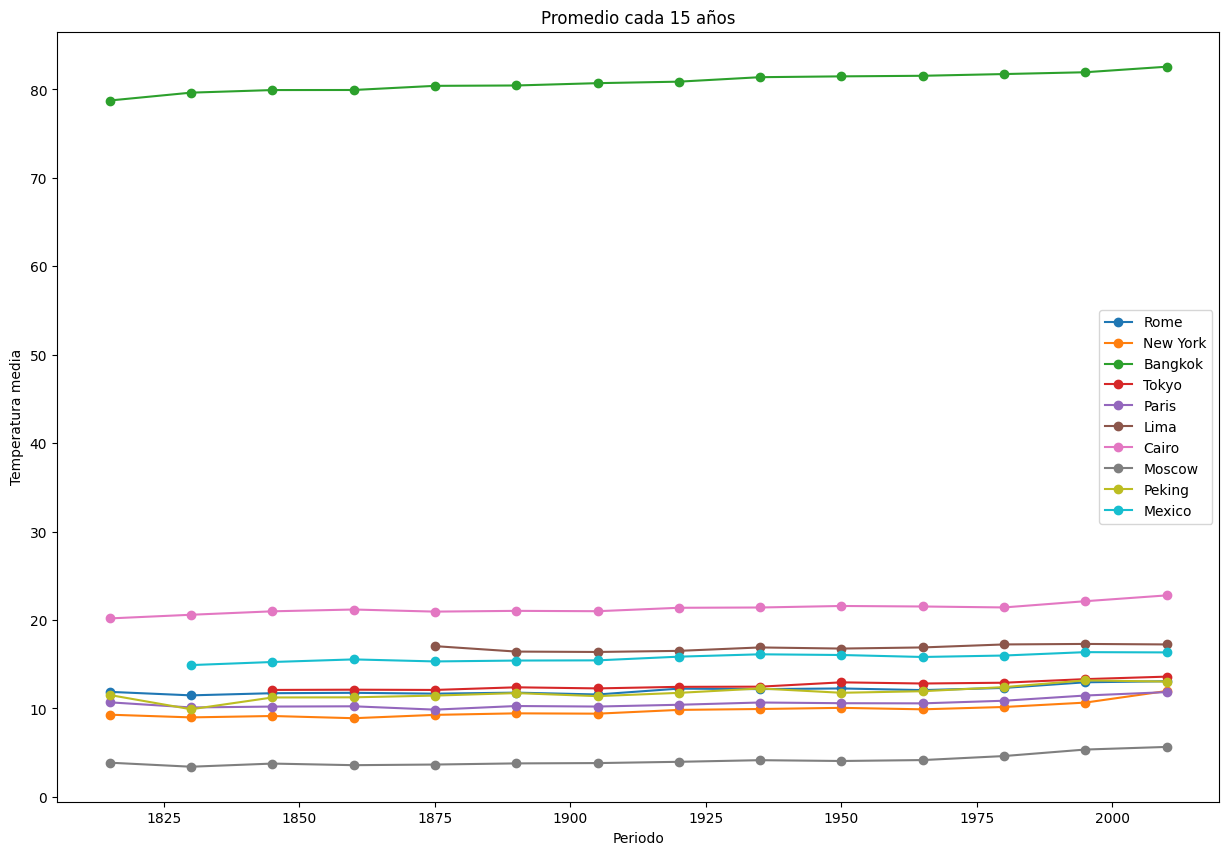

In [ ]:
intervalos = [5, 10, 15]

for intervalo in intervalos:

    plt.figure(figsize=(15,10))

    for ciudad in ciudades:

        df_ciudad = df[df["City"] == ciudad].copy()

        df_ciudad["Periodo"] = (df_ciudad["Year"] // intervalo) * intervalo #ESta parte nos crea que sea cada intervalo de tiempo 

        media_periodo = df_ciudad.groupby("Periodo")["AverageTemperature rellenada"].mean()

        plt.plot(media_periodo.index, media_periodo, label=ciudad, marker = "o")

    plt.title(f"Promedio cada {intervalo} años")
    plt.xlabel("Periodo")
    plt.ylabel("Temperatura media")
    plt.legend()
    plt.show()

# Código previo (borrador)
En esta parte garantiza que hice el programa por mi cuenta o al menos que lo intenté a prueba y error.
Contiene algunos detalles como prints que me ayudaron a la construcción del código, algunas pruebas y parte del psudocódigo. 
Como tal *no forma parte de la tarea, pero lo dejo por cualquier cosa*
No está comentado como el de la entrega. 

In [ ]:
"""vamos a crear una función que haga que si hay un dato faltante lo rellene con el promedio de los extremos


Vamos a pedir los datos ya sea en forma de lista, arreglo np o pd
Vamos a poner los datos salida float y si está vacía colocamos un NaN
Para cada posición i en el arreglo se va a hacer:
    
    Si la posición inicial o la final son valores vacios entonces:
        Recorre la posición hasta encontrar un valor, divide entre dos y colocalo como inicial
        o recorre la posición antes del final con valor, divide entre dos y colocalo como final 

    si la posición incial y la final tienen valores entonces: 
            si en la i-ésima>0 posición está vacía entonces:
                toma los valores de las i-j, i+n-ésimas posiciones que tengan valor
                , calcula el promedio y el valor colocalo en la i-ésima posición
               
        
        
        
        
        
        """

'vamos a crear una función que haga que si hay un dato faltante lo rellene con el promedio de los extremos\n\n\nVamos a pedir los datos ya sea en forma de lista, arreglo np o pd\nVamos a poner los datos salida float y si está vacía colocamos un NaN\nPara cada posición i en el arreglo se va a hacer:\n\n    Si la posición inicial o la final son valores vacios entonces:\n        Recorre la posición hasta encontrar un valor, divide entre dos y colocalo como inicial\n        o recorre la posición antes del final con valor, divide entre dos y colocalo como final \n\n    si la posición incial y la final tienen valores entonces: \n            si en la i-ésima>0 posición está vacía entonces:\n                toma los valores de las i-j, i+n-ésimas posiciones que tengan valor\n                , calcula el promedio y el valor colocalo en la i-ésima posición\n\n\n\n\n\n\n        '

In [ ]:
def datos_A_rellenar(datos):     
    datos_rellenados = []     
    for i in datos:         
        if i != '':             
            datos_rellenados.append(float(i))
        elif i == '':             
            i = np.nan             
            datos_rellenados.append(i)  
    return datos_rellenados

In [ ]:
datos_rellenados = datos_A_rellenar([ '', '', 24, "" , 28.9, "" ])
datos_rellenados

[nan, nan, 24.0, nan, 28.9, nan]

In [ ]:
datos_rellenados

[nan, nan, 24.0, nan, 28.9, nan]

In [ ]:
datos_rellenados 
if np.isnan(datos_rellenados[0]):
    #print("El valor incial está vacío")
    for posicion, valor  in enumerate(datos_rellenados): 
        
        if not np.isnan(valor):
            
            print(posicion,valor)
            datos_rellenados[0] = valor/2 # nuevo valor rellenado
            break # Garantisa el primero 

        elif np.isnan(valor):
            print(f"valor vacio en la posición {posicion + 1}")

if np.isnan(datos_rellenados[-1]):
    #print("El valor final está vacío")
    for posicion, valor  in enumerate(datos_rellenados[::-1]): 
        
        if not np.isnan(valor):
            
            print(posicion,valor)
            datos_rellenados[-1] = valor/2 # nuevo valor rellenado
            break # Garantisa el primer número encontrado

for posicion, valor in enumerate(datos_rellenados):

    if np.isnan(valor):

        anterior = None
        siguiente = None

        # Buscar hacia atrás
        for j in range(posicion - 1, -1, -1):
            if not np.isnan(datos_rellenados[j]):
                anterior = datos_rellenados[j]
                break

        # Buscar hacia adelante
        for j in range(posicion + 1, len(datos_rellenados)):
            if not np.isnan(datos_rellenados[j]):
                siguiente = datos_rellenados[j]
                break

        if anterior is not None and siguiente is not None:
            datos_rellenados[posicion] = (anterior + siguiente) / 2


valor vacio en la posición 1
valor vacio en la posición 2
2 24.0
1 28.9


In [ ]:
datos_rellenados[-1:]

[14.45]

In [ ]:
def datos_A_rellenar(datos):     
    datos_rellenados = []     
    for i in datos:         
        if i != '':             
            datos_rellenados.append(float(i))
        elif i == '':             
            i = np.nan             
            datos_rellenados.append(i)  

    if np.isnan(datos_rellenados[0]):
    
        for posicion, valor  in enumerate(datos_rellenados): 
            
            if not np.isnan(valor):
                datos_rellenados[0] = valor/2 # nuevo valor rellenado
                break # Garantisa el primero 

    if np.isnan(datos_rellenados[-1]):
            #print("El valor final está vacío")
        for posicion, valor  in enumerate(datos_rellenados[::-1]): 
                
            if not np.isnan(valor):
                    
                datos_rellenados[-1] = valor/2 # nuevo valor rellenado
                break # Garantisa el primer número encontrado

    for posicion, valor in enumerate(datos_rellenados):

        if np.isnan(valor):

            anterior = None
            siguiente = None

                # Buscar hacia atrás
            for j in range(posicion - 1, -1, -1):
                if not np.isnan(datos_rellenados[j]):
                    anterior = datos_rellenados[j]
                    break

                # Buscar hacia adelante
            for j in range(posicion + 1, len(datos_rellenados)):
                if not np.isnan(datos_rellenados[j]):
                    siguiente = datos_rellenados[j]
                    break

            if anterior is not None and siguiente is not None:
                datos_rellenados[posicion] = (anterior + siguiente) / 2

       
    return datos_rellenados

In [ ]:
def datos_A_rellenar(datos):
    datos_rellenados = []  #Creamos nuestra lista vacía 

    for i in datos: # Vamos agregando los datos que no son vacios y los que si, los rellenamos con "NaN"
        if not pd.isna(i):
            datos_rellenados.append(float(i))
        else:
            datos_rellenados.append(np.nan)

    if np.isnan(datos_rellenados[0]): # Vamos primero por el extremo si está vacío

        for posicion, valor in enumerate(datos_rellenados): # Buscamos en nuestros datos el primer dato lleno

            if not np.isnan(valor):  
                datos_rellenados[0] = valor / 2
                break # Termina de ejecutarse cuando rellena el valor y ya tenemos el incio 

    if np.isnan(datos_rellenados[-1]): #Básicamente es lo mismo que el de arriba pero empezando por el último 

        for posicion, valor in enumerate(datos_rellenados[::-1]):

            if not np.isnan(valor):
                datos_rellenados[-1] = valor / 2
                break # Ahora tenemos los dos extremos llenos

    for posicion, valor in enumerate(datos_rellenados):
        #Vamos por los que están en medio 
        if np.isnan(valor):
            
            anterior = None #Para que se vea profecional usamos None pero pudimos usar un cero 
            siguiente = None

            # Buscar hacia atrás
            for j in range(posicion - 1, -1, -1):
                if not np.isnan(datos_rellenados[j]):
                    anterior = datos_rellenados[j]
                    break

            # Buscar hacia adelante
            for j in range(posicion + 1, len(datos_rellenados)):
                if not np.isnan(datos_rellenados[j]):
                    siguiente = datos_rellenados[j]
                    break

            if anterior is not None and siguiente is not None:
                datos_rellenados[posicion] = (anterior + siguiente) / 2
 
    return pd.Series(datos_rellenados, index=datos.index)

In [ ]:
df.head(12)

,Date,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,AverageTemperature rellenada
0,1849-01-01,26.704,1.435,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.7040
1,1849-02-01,27.434,1.362,Abidjan,Côte D'Ivoire,5.63N,3.23W,27.4340
2,1849-03-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.7870
3,1849-04-01,26.140,1.387,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.1400
4,1849-05-01,25.427,1.200,Abidjan,Côte D'Ivoire,5.63N,3.23W,25.4270
5,1849-06-01,24.844,1.402,Abidjan,Côte D'Ivoire,5.63N,3.23W,24.8440
6,1849-07-01,24.058,1.254,Abidjan,Côte D'Ivoire,5.63N,3.23W,24.0580
7,1849-08-01,23.576,1.265,Abidjan,Côte D'Ivoire,5.63N,3.23W,23.5760
8,1849-09-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W,24.4195
9,1849-10-01,25.263,1.175,Abidjan,Côte D'Ivoire,5.63N,3.23W,25.2630


In [ ]:

columna_previa  = df["AverageTemperature"]
print(columna_previa.head(12))

columna_rellenada = datos_A_rellenar(columna_previa)
print(columna_rellenada)

0     26.704
1     27.434
2        NaN
3     26.140
4     25.427
5     24.844
6     24.058
7     23.576
8        NaN
9     25.263
10    26.332
11    25.450
Name: AverageTemperature, dtype: float64
0         26.704
1         27.434
2         26.787
3         26.140
4         25.427
           ...  
219570    23.885
219571    17.028
219572    12.399
219573     4.736
219574    -0.822
Length: 219575, dtype: float64


In [ ]:
df["AverageTemperature rellenados"] = columna_rellenada
df

,Date,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,AverageTemperature rellenada,AverageTemperature rellenados
0,1849-01-01,26.704,1.435,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.704,26.704
1,1849-02-01,27.434,1.362,Abidjan,Côte D'Ivoire,5.63N,3.23W,27.434,27.434
2,1849-03-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.787,26.787
3,1849-04-01,26.140,1.387,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.140,26.140
4,1849-05-01,25.427,1.200,Abidjan,Côte D'Ivoire,5.63N,3.23W,25.427,25.427
...,...,...,...,...,...,...,...,...,...
219570,2012-08-01,23.885,0.435,Xian,China,34.56N,108.97E,23.885,23.885
219571,2012-09-01,17.028,1.405,Xian,China,34.56N,108.97E,17.028,17.028
219572,2012-10-01,12.399,0.526,Xian,China,34.56N,108.97E,12.399,12.399
219573,2012-11-01,4.736,0.519,Xian,China,34.56N,108.97E,4.736,4.736


In [ ]:
def histograma_general(columna_df):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.hist(columna_df, density=True, bins=60 , alpha=0.6, color="blue", label = "Datos sin rellenar")
    plt.legend(loc = "best")
    plt.subplot(1, 2, 2)
    plt.hist(datos_A_rellenar(columna_df), bins=60,  density=True, alpha=0.6, color="blue", label = "Rellenados")
    plt.legend(loc = "best")
    plt.show()

In [ ]:
(df["Date"].iloc[:10])

0    1849-01-01
1    1849-02-01
2    1849-03-01
3    1849-04-01
4    1849-05-01
5    1849-06-01
6    1849-07-01
7    1849-08-01
8    1849-09-01
9    1849-10-01
Name: Date, dtype: str

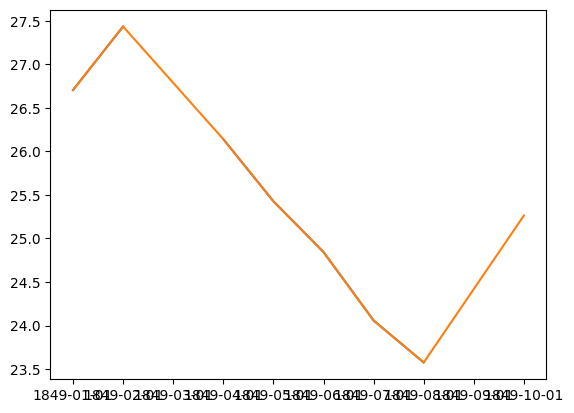

In [ ]:
plt.plot(df["Date"].iloc[:10], df["AverageTemperature"].iloc[:10])
plt.plot(df["Date"].iloc[:10], df["AverageTemperature rellenados"].iloc[:10])

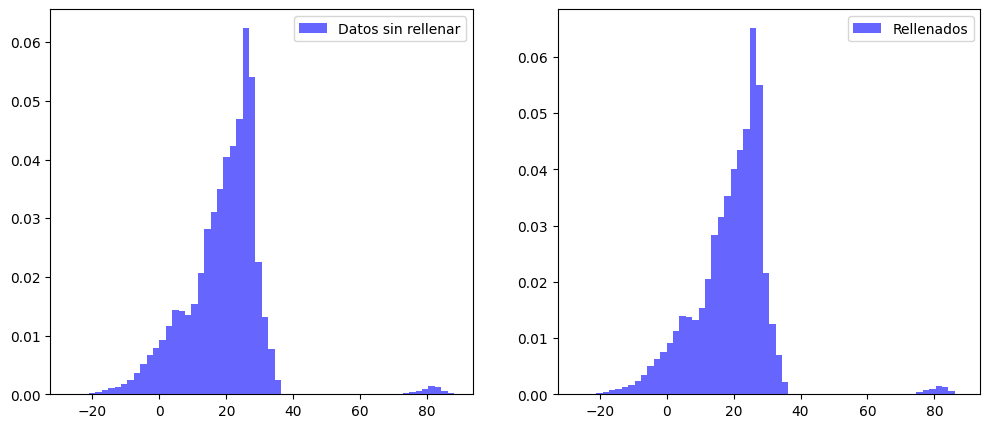

In [ ]:
columna_previa  = df["AverageTemperature"]
histograma_general(columna_previa)

## Parte 3

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df

,Date,AverageTemperature,AverageTemperatureUncertainty,City,Country,Latitude,Longitude,AverageTemperature rellenada,AverageTemperature rellenados,Year
0,1849-01-01,26.704,1.435,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.704,26.704,1849
1,1849-02-01,27.434,1.362,Abidjan,Côte D'Ivoire,5.63N,3.23W,27.434,27.434,1849
2,1849-03-01,NaN,NaN,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.787,26.787,1849
3,1849-04-01,26.140,1.387,Abidjan,Côte D'Ivoire,5.63N,3.23W,26.140,26.140,1849
4,1849-05-01,25.427,1.200,Abidjan,Côte D'Ivoire,5.63N,3.23W,25.427,25.427,1849
...,...,...,...,...,...,...,...,...,...,...
219570,2012-08-01,23.885,0.435,Xian,China,34.56N,108.97E,23.885,23.885,2012
219571,2012-09-01,17.028,1.405,Xian,China,34.56N,108.97E,17.028,17.028,2012
219572,2012-10-01,12.399,0.526,Xian,China,34.56N,108.97E,12.399,12.399,2012
219573,2012-11-01,4.736,0.519,Xian,China,34.56N,108.97E,4.736,4.736,2012


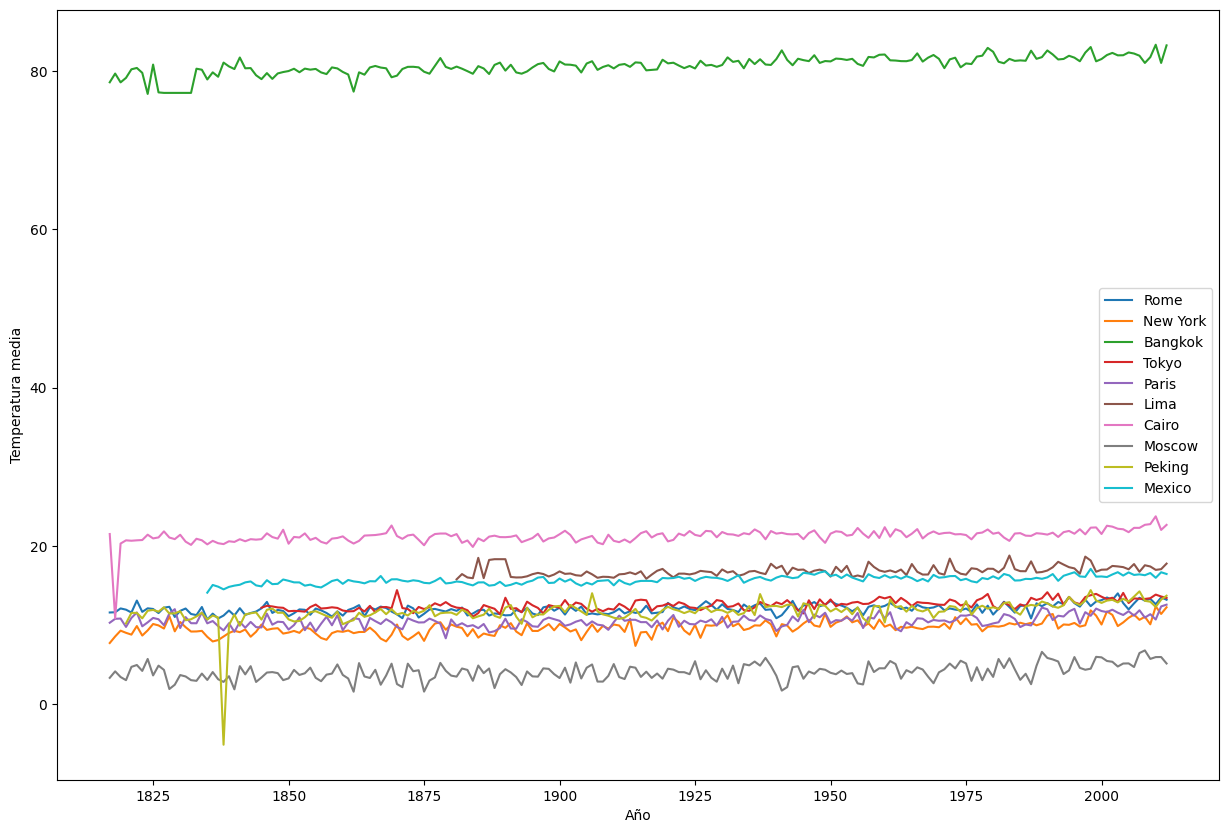

In [ ]:
ciudades = ["Rome", "New York", "Bangkok", "Tokyo", "Paris", "Lima", "Cairo", "Moscow", "Peking", "Mexico"]
plt.figure(figsize=(15,10))
for i in ciudades:
    #print(i)
    df_por_cuidad_i = df[df["City"] == i]
    #print(df_por_cuidad_i)
    media_anual_i = df_por_cuidad_i.groupby('Year')["AverageTemperature rellenados"].mean()
    #print(media_anual_i.head(2))
    plt.plot(media_anual_i.index, media_anual_i, label = i)
plt.xlabel("Año")
plt.ylabel("Temperatura media")
plt.legend(loc = "best")
plt.show()


In [ ]:
media_anual = .groupby('Year')['AverageTemperature'].mean()
print(media_anual)


In [ ]:
df_por_cuidad_i = df[df["AverageTemperature"] == "Mexico"]
print(df_por_cuidad_i)

Empty DataFrame
Columns: [Date, AverageTemperature, AverageTemperatureUncertainty, City, Country, Latitude, Longitude, AverageTemperature rellenada, AverageTemperature rellenados]
Index: []
